# Stage 6: Reporting (Layer 4)

Runs `src/reporting/aggregator.py` and `src/reporting/visualiser.py` against
`outputs/results/full_benchmark.csv`, scoped to the finalised study:
**CTGAN + TVAE** on **diabetes_130us + acs_income** (16 combos).

`copulagan` and `home_credit` rows are filtered out (not deleted) —
copulagan showed an unresolved DCR anomaly under DP training, and
home_credit's DP generation timed out against Kaggle's 12-hour session
limit. Both are still available in `full_benchmark.csv` for an appendix
note if you want one.

Outputs:
- `outputs/results/stage6_master_matrix.csv` — the Layer 4 comparison matrix
- `outputs/results/stage6_epsilon_trend_summary.csv` — monotonicity check per (dataset, generator)
- `outputs/plots/tradeoff_curves/` — utility & MIA AUC vs epsilon
- `outputs/plots/tstr_comparisons/` — Pareto scatter + TSTR bar charts
- `outputs/plots/correlation_heatmaps/` — metric heatmaps (see visualiser.py docstring re: naming)

In [1]:
import os
os.chdir('..')

import yaml
import pandas as pd

with open('config.yaml') as f:
    config = yaml.safe_load(f)

from src.reporting.aggregator import BenchmarkAggregator
from src.reporting.visualiser import BenchmarkVisualiser

agg = BenchmarkAggregator(config)
viz = BenchmarkVisualiser(config)

df = agg.load()
print(f'{len(df)} rows in scope')
df[['dataset', 'generator', 'epsilon']].value_counts().sort_index()

16 rows in scope


dataset         generator  epsilon
acs_income      ctgan      nodp       1
                           10         1
                           5          1
                           1          1
                tvae       nodp       1
                           10         1
                           5          1
                           1          1
diabetes_130us  ctgan      nodp       1
                           10         1
                           5          1
                           1          1
                tvae       nodp       1
                           10         1
                           5          1
                           1          1
Name: count, dtype: int64

## Master comparison matrix

In [2]:
matrix = agg.master_matrix(df)
agg.save(matrix, 'stage6_master_matrix.csv')
matrix

,dataset,generator,epsilon,label,utility_ratio,tstr_auc,trtr_auc,tstr_f1,tstr_accuracy,stat_overall,wasserstein_mean,corr_diff,cat_similarity,mia_auc,mia_privacy_score,dcr_mean,dcr_median,nndr_mean,nndr_median,dist_privacy_score
0,acs_income,ctgan,nodp,ctgan_nodp,0.974668,0.872690,0.895371,0.782223,0.780467,0.929042,0.119493,0.012286,0.906001,0.637356,0.725289,26.334375,39.408121,9.723323e-01,0.921386,0.960693
1,acs_income,ctgan,10,ctgan_eps10,0.979872,0.877349,0.895371,0.795323,0.795850,0.974966,0.024913,0.025032,0.973625,0.621084,0.757831,27.412065,41.255301,9.806928e-01,0.925040,0.962520
2,acs_income,ctgan,5,ctgan_eps5,0.979349,0.876881,0.895371,0.796201,0.796949,0.978526,0.026183,0.013876,0.974781,0.616746,0.766508,25.981555,33.354214,9.815041e-01,0.922976,0.961488
3,acs_income,ctgan,1,ctgan_eps1,0.979629,0.877131,0.895371,0.794962,0.795543,0.979737,0.023463,0.015212,0.977120,0.610569,0.778862,25.301922,27.037005,9.767414e-01,0.923214,0.961607
4,acs_income,tvae,nodp,tvae_nodp,0.961008,0.860575,0.895492,0.779452,0.783329,0.944628,0.042218,0.036520,0.909626,0.689626,0.620748,6.586314,6.403124,4.000001e+06,0.991629,0.995125
5,acs_income,tvae,10,tvae_eps10,0.513905,0.450805,0.877213,0.508681,0.533386,0.650124,0.738714,0.152315,0.507418,0.803298,0.393403,13.590924,13.674794,9.582318e-01,0.962904,0.981451
6,acs_income,tvae,5,tvae_eps5,0.471973,0.418323,0.886327,0.466906,0.465132,0.647236,0.734484,0.164506,0.506433,0.827285,0.345430,13.882357,13.711309,9.973684e-01,0.971969,0.985984
7,acs_income,tvae,1,tvae_eps1,0.674655,0.602379,0.892869,0.566974,0.563514,0.653737,0.639853,0.195493,0.514927,0.893039,0.213923,8.995044,8.426150,9.526738e-01,0.820529,0.910202
8,diabetes_130us,ctgan,nodp,ctgan_nodp,0.843707,0.576382,0.683155,0.383824,0.538518,0.907460,0.197699,0.049722,0.934813,0.636841,0.726318,7.750014,7.416198,1.006031e+00,0.990148,0.994858
9,diabetes_130us,ctgan,10,ctgan_eps10,0.878566,0.600197,0.683155,0.477271,0.550850,0.970418,0.028918,0.055825,0.992232,0.602615,0.794770,7.598554,7.280110,1.006982e+00,0.990338,0.994918


## Epsilon trend summary

Quick scan: does utility decrease and does MIA AUC move toward 0.5 as
epsilon goes nodp → 10 → 5 → 1? (`utility_monotonic_decreasing` /
`mia_monotonic_improving` are strict — a single non-monotonic step flips
them to False, so treat these as a flag to go look at the curve, not a
pass/fail grade.)

In [3]:
trend = agg.epsilon_trend_summary(df)
agg.save(trend, 'stage6_epsilon_trend_summary.csv')
trend

,dataset,generator,utility_nodp,utility_eps1,utility_delta,utility_monotonic_decreasing,mia_nodp,mia_eps1,mia_delta_toward_0.5,mia_monotonic_improving
0,acs_income,ctgan,0.974668,0.979629,0.004961,False,0.637356,0.610569,0.026787,True
1,acs_income,tvae,0.961008,0.674655,-0.286353,False,0.689626,0.893039,-0.203412,False
2,diabetes_130us,ctgan,0.843707,0.905906,0.062199,False,0.636841,0.602126,0.034715,False
3,diabetes_130us,tvae,0.903520,0.732871,-0.170650,False,0.664701,0.698874,-0.034173,False


## Pareto frontier

A (generator, epsilon) combo is Pareto-optimal if no other combo has
both higher utility AND equal-or-better privacy. Computed separately per
dataset since privacy/utility scales aren't necessarily comparable across
domains.

In [4]:
pareto_by_dataset = {}
for dataset_name in sorted(df['dataset'].unique()):
    pareto_by_dataset[dataset_name] = agg.pareto_frontier(df, dataset_name=dataset_name)
    print(f'\n--- {dataset_name} ---')
    cols = ['generator', 'epsilon', 'utility_ratio', 'mia_auc', 'is_pareto_optimal']
    print(pareto_by_dataset[dataset_name][cols].to_string(index=False))


--- acs_income ---
generator epsilon  utility_ratio  mia_auc  is_pareto_optimal
    ctgan    nodp       0.974668 0.637356              False
    ctgan      10       0.979872 0.621084               True
    ctgan       5       0.979349 0.616746              False
    ctgan       1       0.979629 0.610569               True
     tvae    nodp       0.961008 0.689626              False
     tvae      10       0.513905 0.803298              False
     tvae       5       0.471973 0.827285              False
     tvae       1       0.674655 0.893039              False

--- diabetes_130us ---
generator epsilon  utility_ratio  mia_auc  is_pareto_optimal
    ctgan    nodp       0.843707 0.636841              False
    ctgan      10       0.878566 0.602615              False
    ctgan       5       0.884728 0.616256              False
    ctgan       1       0.905906 0.602126               True
     tvae    nodp       0.903520 0.664701              False
     tvae      10       0.740995 0.698155

## Plots

In [5]:
for dataset_name in sorted(df['dataset'].unique()):
    viz.plot_tradeoff_curves(df, dataset_name)
    viz.plot_pareto_scatter(pareto_by_dataset[dataset_name], dataset_name)
    viz.plot_tstr_comparison(df, dataset_name)

viz.plot_tradeoff_curves_combined(df)
viz.plot_metric_heatmap(df, 'utility_ratio')
viz.plot_metric_heatmap(df, 'mia_auc')

print('All plots saved under outputs/plots/')

All plots saved under outputs/plots/


## Headline figure

The combined trade-off figure is the single clearest summary of the
study's main finding: CTGAN stays flat and well-behaved across ε; TVAE
takes a large utility hit that does NOT come with the expected MIA
privacy improvement.

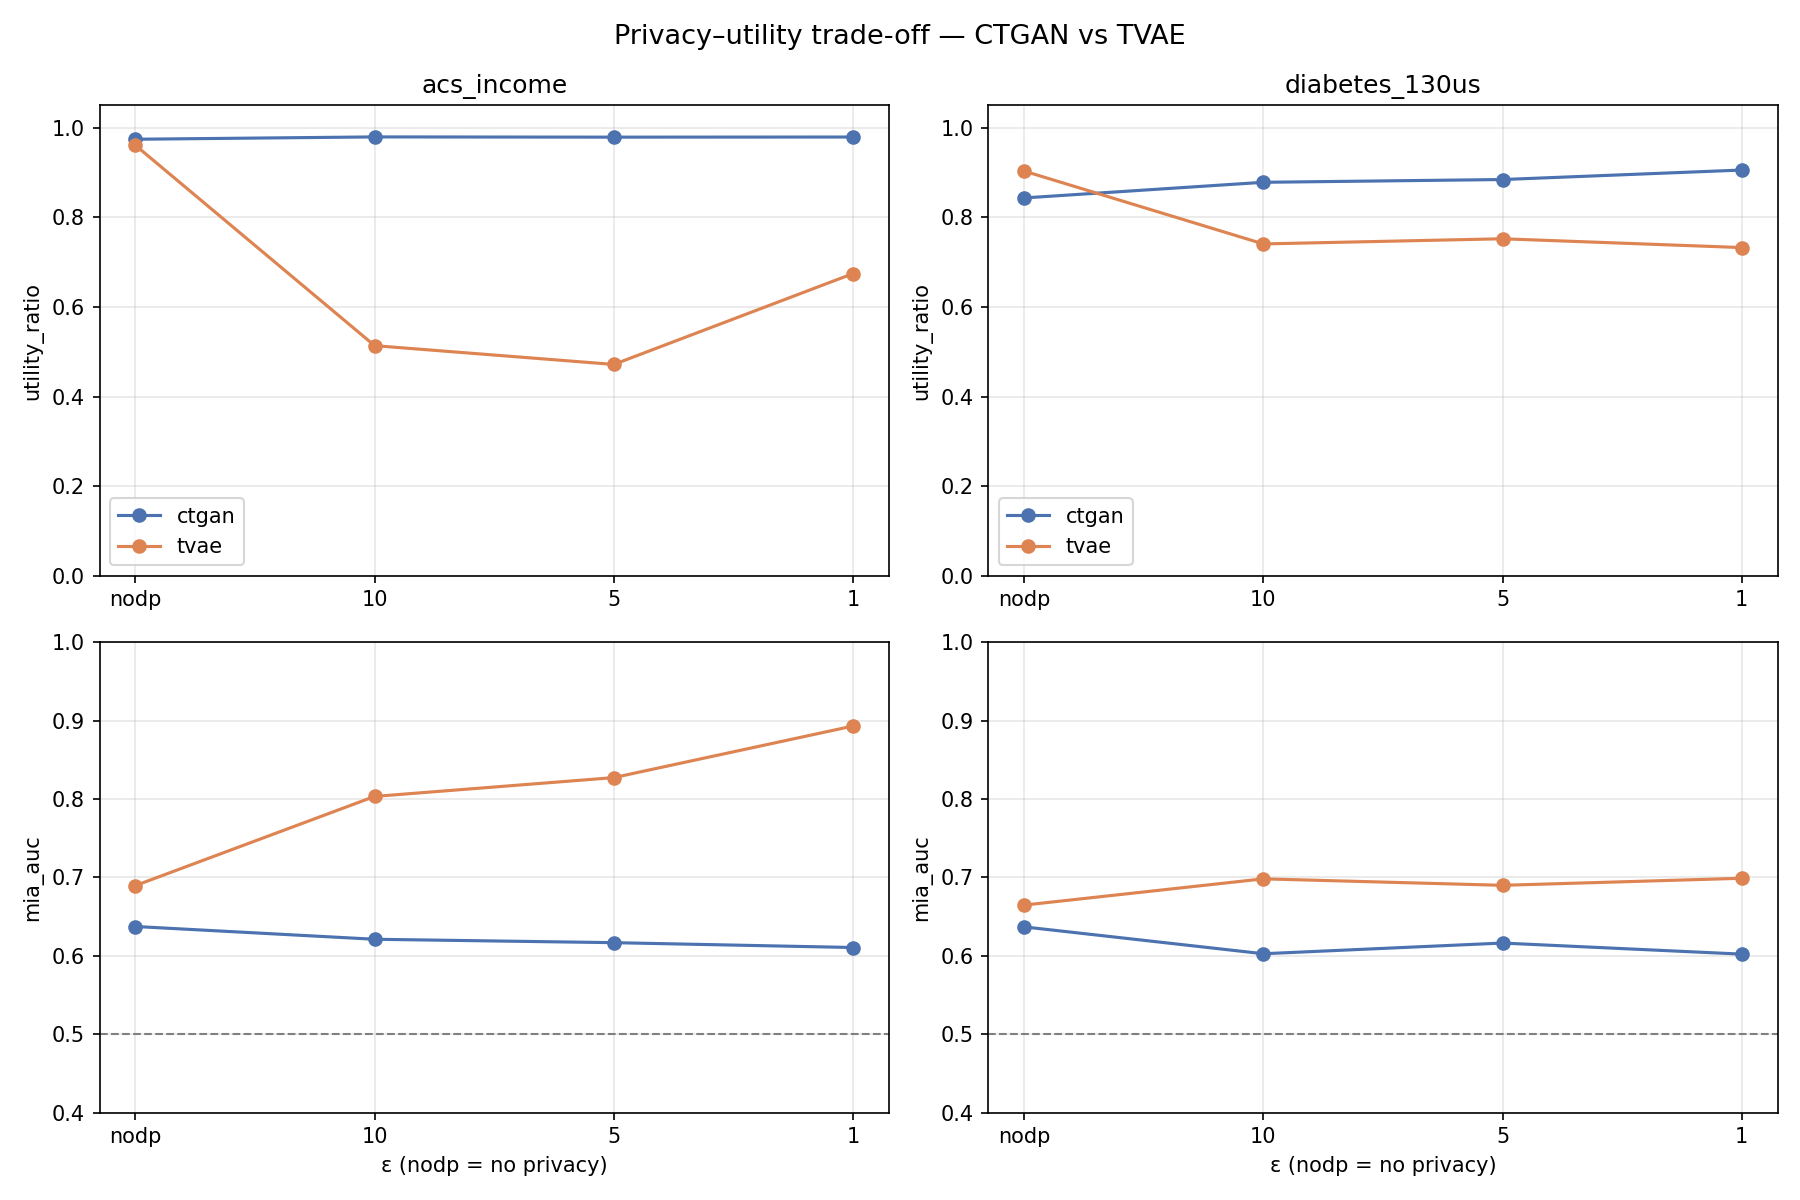

In [6]:
from IPython.display import Image, display
display(Image(filename='outputs/plots/tradeoff_curves/combined_tradeoff.png'))